<a href="https://colab.research.google.com/github/Ismot10/Disaster-Management-and-Early-Warning-System-App/blob/main/WILDFIRE_ML_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# CELL 1 — Install & Imports
# ============================================
!pip install pandas numpy matplotlib scikit-learn tensorflow imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
# ============================================
# CELL 2 — Upload Dataset
# ============================================
from google.colab import files
uploaded = files.upload()


Saving wildfire_dataset.csv to wildfire_dataset.csv


In [ ]:
# ============================================
# CELL 3 — Load & Clean Dataset
# ============================================

df = pd.read_csv("wildfire_dataset.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"])
df = df.sort_values("timestamp")


In [ ]:
# ============================================
# CELL 4 — Feature selection
# ============================================

FEATURES = ["temperature", "humidity", "gas_value", "flame_detected"]
TARGET = "wildfire_detected"

df["flame_detected"] = df["flame_detected"].astype(str).str.lower().map({
    "yes": 1, "no": 0
})

df["wildfire_detected"] = df["wildfire_detected"].astype(str).str.lower().map({
    "yes": 1, "no": 0
})

df[FEATURES] = df[FEATURES].apply(pd.to_numeric, errors="coerce")
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

df = df.dropna(subset=FEATURES + [TARGET])

X_raw = df[FEATURES]
y_raw = df[TARGET]


In [ ]:
# ============================================
# CELL 5 — Scaling + Rolling Window Creation
# ============================================

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

WINDOW_SIZE = 5

X_windows = []
y_windows = []

for i in range(WINDOW_SIZE, len(X_scaled)):
    window = X_scaled[i - WINDOW_SIZE:i]
    X_windows.append(window.flatten())   # 5 × 4 = 20 features
    y_windows.append(y_raw.iloc[i])

X = np.array(X_windows)
y = np.array(y_windows)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (3964, 20)
y shape: (3964,)


In [ ]:
# ============================================
# CELL 6 — Balance dataset (FIXED)
# ============================================

from collections import Counter
print("Before balancing:", Counter(y))

minority = min(Counter(y).values())

if minority >= 2:
    k = min(5, minority - 1)
    smote = SMOTE(random_state=42, k_neighbors=k)
    X_balanced, y_balanced = smote.fit_resample(X, y)
else:
    print("⚠️ Too few minority samples — skipping SMOTE")
    X_balanced, y_balanced = X, y

print("After balancing:", Counter(y_balanced))


Before balancing: Counter({np.int64(0): 3338, np.int64(1): 626})
After balancing: Counter({np.int64(0): 3338, np.int64(1): 3338})


In [ ]:
# ============================================
# CELL 7 — Train / Test Split (SAFE)
# ============================================

label_counts = Counter(y_balanced)
print("Label counts:", label_counts)

use_stratify = all(v >= 2 for v in label_counts.values())

if use_stratify:
    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced,
        y_balanced,
        test_size=0.2,
        random_state=42,
        shuffle=True,
        stratify=y_balanced
    )
else:
    print("⚠️ Stratify disabled")
    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced,
        y_balanced,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Label counts: Counter({np.int64(0): 3338, np.int64(1): 3338})
Train: (5340, 20)
Test : (1336, 20)


In [ ]:
# ============================================
# CELL 7.5 — Class weights
# ============================================

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)


Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


In [ ]:
# ============================================
# CELL 8 — Model
# ============================================

model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(16, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (4.75 KB)

 Trainable params: 1,217 (4.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# CELL 9 — Train
# ============================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight
)


Epoch 1/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7762 - loss: 0.5180 - val_accuracy: 0.9410 - val_loss: 0.2123
Epoch 2/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9246 - loss: 0.2594 - val_accuracy: 0.9803 - val_loss: 0.1176
Epoch 3/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9498 - loss: 0.1958 - val_accuracy: 0.9813 - val_loss: 0.0897
Epoch 4/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9599 - loss: 0.1506 - val_accuracy: 0.9813 - val_loss: 0.0767
Epoch 5/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9584 - loss: 0.1357 - val_accuracy: 0.9822 - val_loss: 0.0687
Epoch 6/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9648 - loss: 0.1229 - val_accuracy: 0.9803 - val_loss: 0.0625
Epoch 7/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9691 - loss: 0.1113 - val_accuracy: 0.9850 - val_loss: 0.0633
Epoch 8/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9651 - loss: 0.1131 - val_accuracy: 

In [ ]:
# ============================================
# CELL 10 — Evaluation
# ============================================

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 99.1 %

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       668
           1       1.00      0.99      0.99       668

    accuracy                           0.99      1336
   macro avg       0.99      0.99      0.99      1336
weighted avg       0.99      0.99      0.99      1336



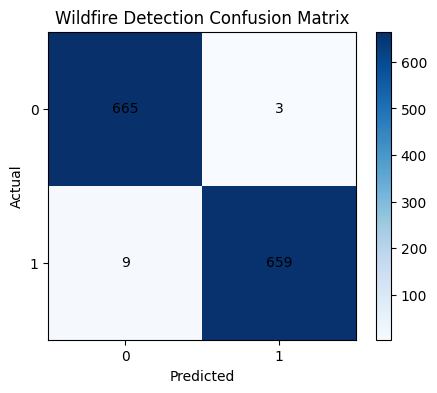

In [ ]:
# ============================================
# CELL 11 — Confusion Matrix (COLORED)
# ============================================

y_test_flat = np.array(y_test).reshape(-1)
y_pred_flat = np.array(y_pred).reshape(-1)

labels = np.unique(np.concatenate([y_test_flat, y_pred_flat]))

cm = confusion_matrix(y_test_flat, y_pred_flat, labels=labels)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")   # ← color changed here
plt.title("Wildfire Detection Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ============================================
# CELL 12 — Save Model
# ============================================

model.save("wildfire_classifier.keras")
print("✅ Model saved")


✅ Model saved


In [ ]:
# ============================================
# CELL 13 — Convert to TFLite (Flutter-safe)
# ============================================

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

converter._experimental_lower_tensor_list_ops = True
converter.experimental_enable_resource_variables = False
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("wildfire_model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Wildfire TFLite model created")


Saved artifact at '/tmp/tmpvhhqoy_q'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137266279847248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137266279848592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137266279849936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137266279849168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137266279848016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137266279850128: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Wildfire TFLite model created


In [ ]:
# ============================================
# CELL 14 — Download
# ============================================

from google.colab import files
files.download("wildfire_model.tflite")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>